In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql


query = """SELECT
t.state_code AS State,
COUNT(*) AS State_Loans,
SUM(CASE WHEN t.agency = 'F' THEN 1 ELSE 0 END) AS FHA_Loans,
SUM(CASE WHEN t.agency = 'F' THEN t2.unpaid_principal_balance ELSE 0 END) AS Total_FHA_UPB,
ROUND(CAST(SUM(CASE WHEN t.agency = 'F' THEN 1 ELSE 0 END) AS FLOAT)/COUNT(*) * 100, 2) AS Percent_State_FHA,
ROUND(CAST(SUM(CASE WHEN t.agency = 'F' THEN t2.unpaid_principal_balance ELSE 0 END) AS FLOAT)/SUM(t2.unpaid_principal_balance) * 100, 2) AS Percent_State_UPB_FHA,
SUM(CASE WHEN t.agency = 'F' AND t2.months_delinquent <> 0 THEN 1 ELSE 0 END) AS Total_FHA_Delinquencies
FROM
gnma_static_table t
LEFT JOIN mbs_loans_monthly t2 ON t2.disclosure_sequence_number = t.disclosure_sequence_number
GROUP BY t.state_code"""

df = read_sql(query)


print(df.head())

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_19976\3971900505.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  state  state_loans  fha_loans  total_fha_upb  percent_state_fha  \
0    AK        38403      13049   2.925620e+09              33.98   
1    AL       279993     159077   2.257147e+10              56.81   
2    AR       154830      84368   1.089203e+10              54.49   
3    AZ       344066     206192   4.429750e+10              59.93   
4    CA       798834     519100   1.539470e+11              64.98   

   percent_state_upb_fha  total_fha_delinquencies  
0                  30.43                      989  
1                  50.24                    21004  
2                  51.83                     9544  
3                  56.28                    22163  
4                  59.53                    55030  


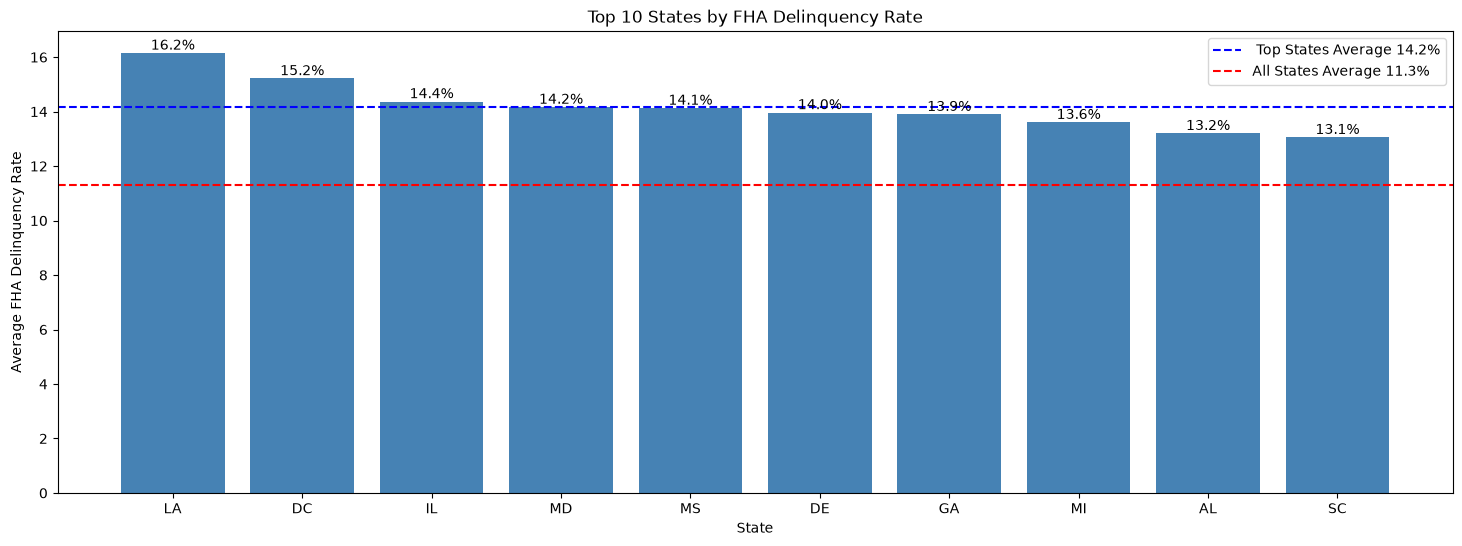

In [3]:
df['fha_delinquency_rate'] = (df['total_fha_delinquencies']/df['fha_loans'])* 100

top_states = df.nlargest(10,'fha_delinquency_rate')

plt.figure(figsize=(18,6))
bars = plt.bar(top_states['state'], top_states['fha_delinquency_rate'], color='steelblue',)
plt.bar_label(bars,fmt='%.1f%%')
top_avg = top_states['fha_delinquency_rate'].mean()
plt.axhline(top_avg, color='blue', linestyle='--', linewidth=1.5,label=f' Top States Average {top_avg:.1f}%')
avg = df['fha_delinquency_rate'].mean()
plt.axhline(avg, color='red', linestyle='--', linewidth=1.5,label=f'All States Average {avg:.1f}%')
plt.title('Top 10 States by FHA Delinquency Rate')
plt.xlabel('State')
plt.ylabel('Average FHA Delinquency Rate')
plt.legend()